[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [ ]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Semilla para reproducibilidad
RANDOM_STATE = 42

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos

Cargamos el **Bank Marketing dataset** desde OpenML. Es el dataset original de UCI, ampliamente usado en investigación para predecir la suscripción de depósitos a plazo en campañas de marketing telefónico.

### Descripción del dataset

Los datos provienen de campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. El objetivo es predecir si un cliente suscribirá un **depósito a plazo** tras la campaña.

| Variable | Descripción |
|---|---|
| `age` | Edad del cliente |
| `job` | Tipo de trabajo |
| `marital` | Estado civil |
| `education` | Nivel educativo |
| `default` | ¿Tiene crédito en mora? |
| `balance` | Saldo anual promedio (euros) |
| `housing` | ¿Tiene crédito hipotecario? |
| `loan` | ¿Tiene crédito personal? |
| `contact` | Tipo de contacto |
| `day` | Día del último contacto |
| `month` | Mes del último contacto |
| `duration` | Duración de la llamada (segundos) |
| `campaign` | Nº de contactos durante esta campaña |
| `pdays` | Días desde el último contacto previo |
| `previous` | Nº de contactos previos a esta campaña |
| `poutcome` | Resultado de la campaña anterior |
| `deposit` | **Target:** ¿Suscribió el depósito? (yes/no) |

In [ ]:
# Cargamos el dataset desde OpenML
# data_id=1461 corresponde al Bank Marketing original de UCI
from sklearn.datasets import fetch_openml

try:
    bunch = fetch_openml(data_id=1461, as_frame=True, parser='auto')
    df = bunch.frame.copy()
    
    # OpenML devuelve nombres genéricos (V1, V2, ..., Class)
    # Los renombramos a los nombres reales del Bank Marketing
    rename_map = {
        'V1': 'age',
        'V2': 'job',
        'V3': 'marital',
        'V4': 'education',
        'V5': 'default',
        'V6': 'balance',
        'V7': 'housing',
        'V8': 'loan',
        'V9': 'contact',
        'V10': 'day',
        'V11': 'month',
        'V12': 'duration',
        'V13': 'campaign',
        'V14': 'pdays',
        'V15': 'previous',
        'V16': 'poutcome',
        'Class': 'deposit'
    }
    df = df.rename(columns=rename_map)
    
    # El target viene como 1 y 2 (categorías); lo convertimos a yes/no
    # 1 = no (cliente no suscribió), 2 = yes (cliente suscribió)
    df['deposit'] = df['deposit'].map({'1': 'no', '2': 'yes', 1: 'no', 2: 'yes'})
    
    print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde OpenML: {e}')
    print('Si falla, descarga "bank.csv" desde Kaggle y cárgalo con: df = pd.read_csv("bank.csv")')
    raise

df.head()

Dataset cargado desde OpenML — 45211 registros, 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


---
## 3. Etapa 2 — Exploración y preparación de datos

In [ ]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  deposit    45211 non-null  category
dtypes: category(10), int64(7)
memory usage: 2.8 MB




,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [ ]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 45211


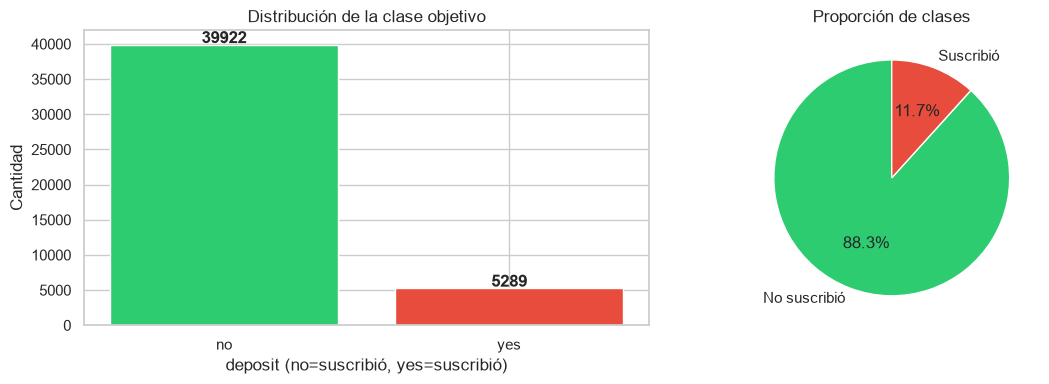

In [ ]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['deposit'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('deposit (no=suscribió, yes=suscribió)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['No suscribió', 'Suscribió'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

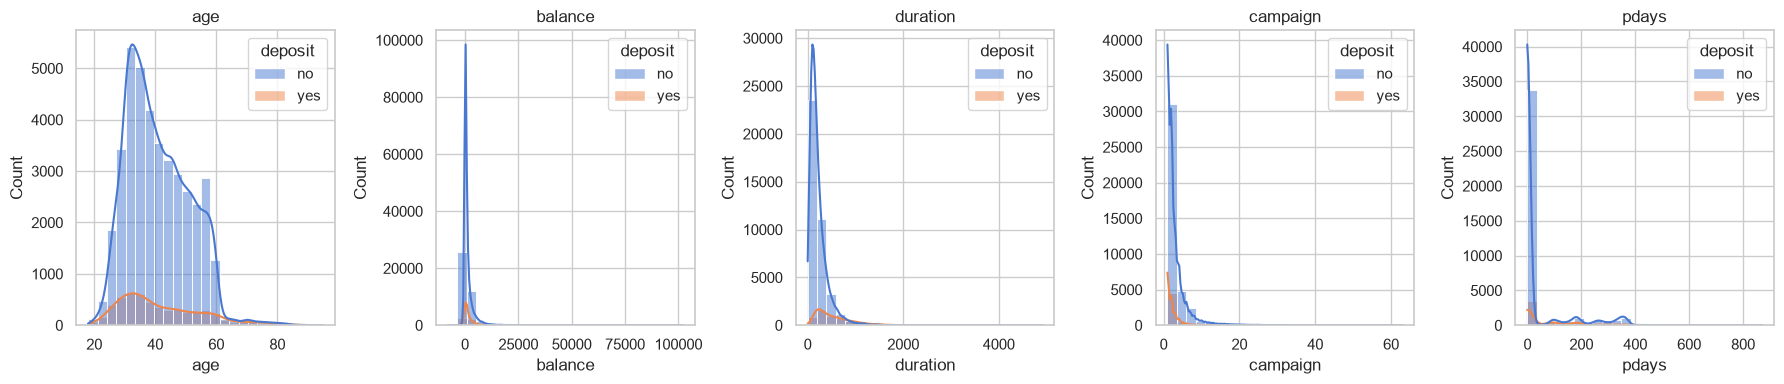

In [ ]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='deposit', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

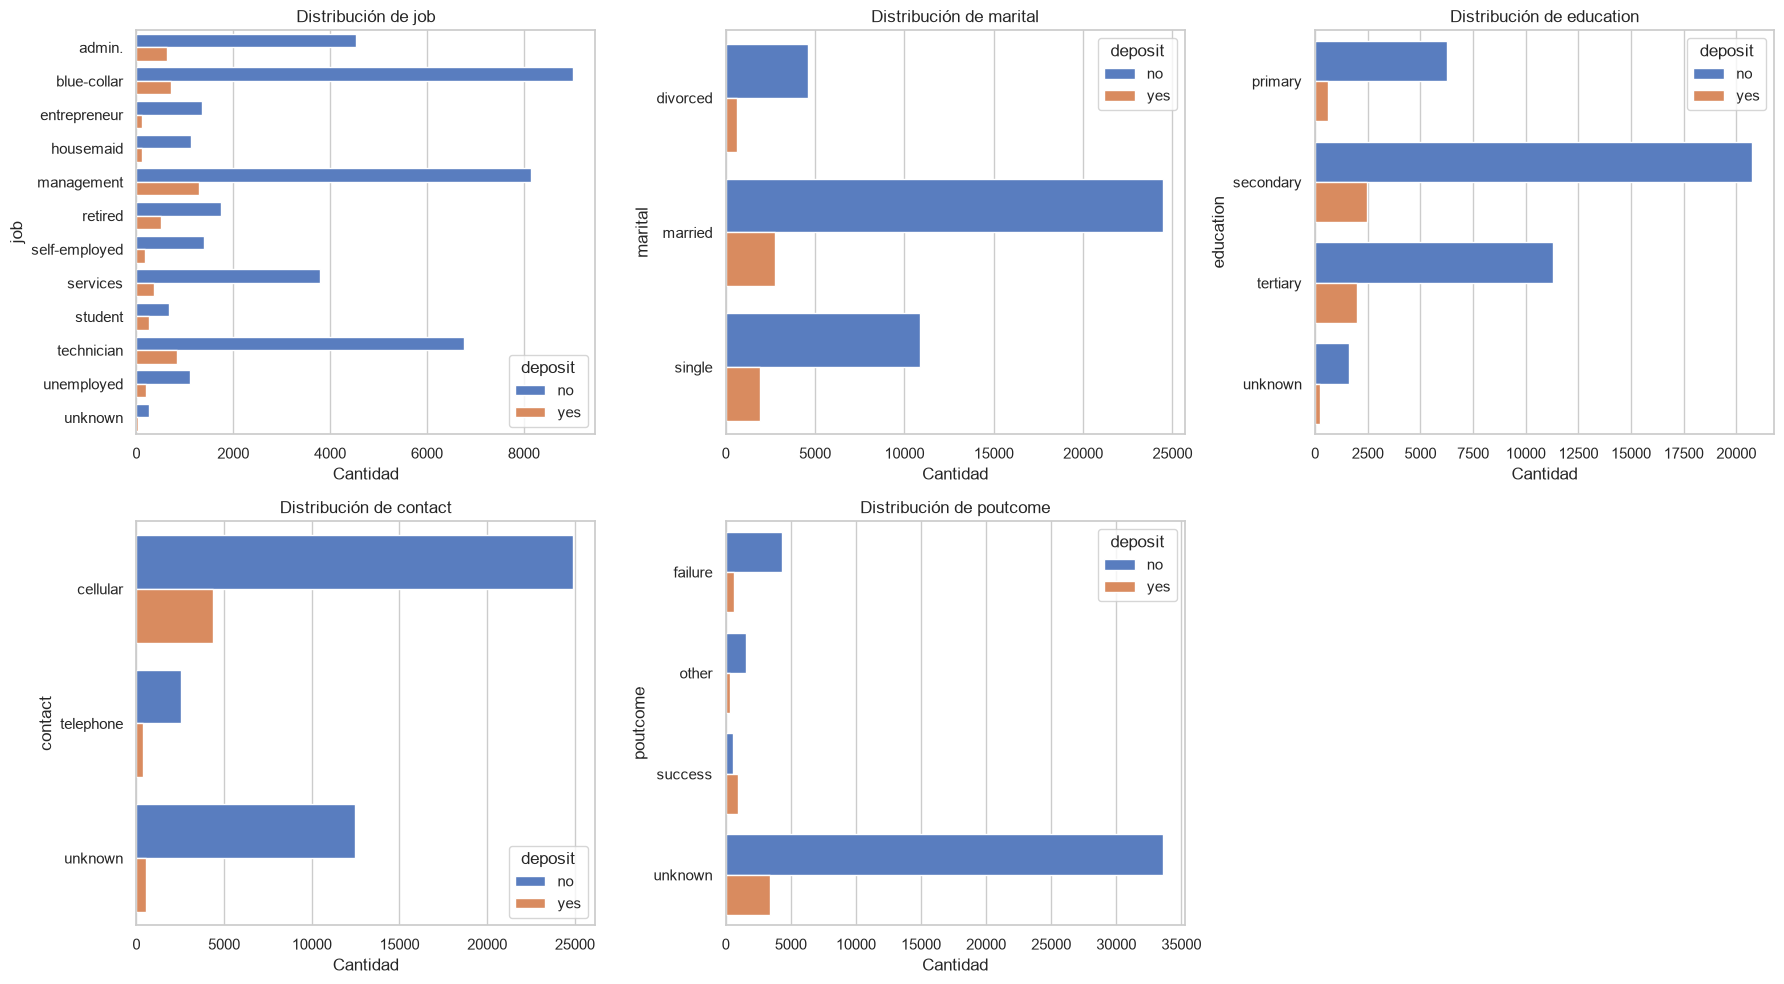

In [ ]:
# 3.5  Distribución de variables categóricas clave
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, hue='deposit', ax=axes[i], palette='muted')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Cantidad')

# Ocultar el subplot sobrante
axes[-1].axis('off')

plt.tight_layout()
plt.show()

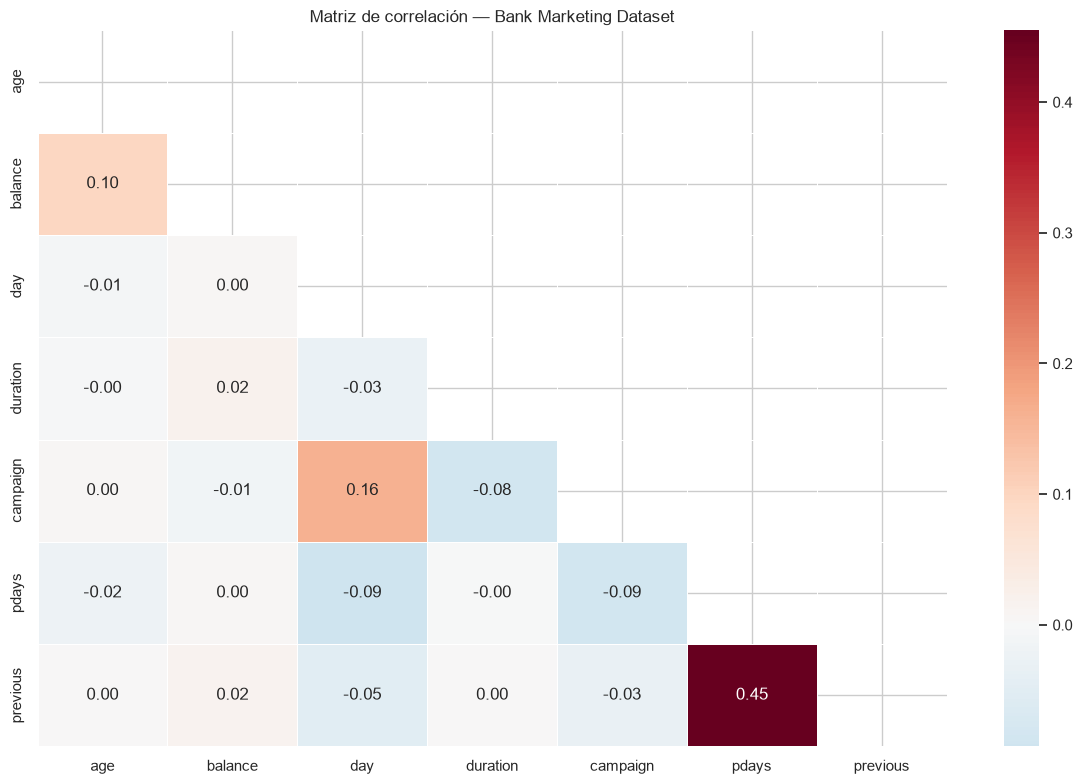

In [ ]:
# 3.6  Matriz de correlación (solo variables numéricas)
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Bank Marketing Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

Antes de entrenar los modelos, debemos preparar los datos:

1. **Mapear las variables binarias** (`default`, `housing`, `loan`, `deposit`) de `yes`/`no` a `1`/`0`.
2. **Separar features y target**.
3. **Dividir en train/test** con estratificación (80/20).
4. **Definir el preprocesador** (`ColumnTransformer`): escalar numéricas y aplicar One-Hot a las categóricas.

In [ ]:
# 4.1  Mapeo de variables binarias yes/no → 1/0 (versión robusta)
binary_cols = ['default', 'housing', 'loan', 'deposit']

for col in binary_cols:
    # Primero verificar valores únicos (diagnóstico)
    print(f'{col}: valores únicos = {df[col].unique()}')
    
    # Convertir a string por si acaso (evita problemas con tipos category)
    df[col] = df[col].astype(str).str.strip().str.lower()
    
    # Mapear con manejo de valores desconocidos
    mapping = {'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0}
    df[col] = df[col].map(mapping)
    
    # Si quedan NaN, mostrarlos (para debug)
    nans = df[col].isna().sum()
    if nans > 0:
        print(f'  ⚠️ {col} tiene {nans} valores sin mapear.')
        print(f'  Valores problemáticos: {df.loc[df[col].isna(), col].unique() if nans < 20 else "(muchos)"}')

print('\nMapeo de binarias completado.')

# Convertir a int solo si no quedan NaN
for col in binary_cols:
    if df[col].isna().sum() == 0:
        df[col] = df[col].astype(int)
        print(f'  {col}: convertido a int64 ✓')
    else:
        print(f'  {col}: quedan NaN, no se convierte a int')

# Unificar categóricas
for col in ['job', 'marital', 'education', 'contact', 'month', 'poutcome']:
    df[col] = df[col].astype('category')

# Verificación final
print(f'\nDtypes después del mapeo:')
print(df[binary_cols].dtypes)
print(f'\nValores únicos:')
for col in binary_cols:
    print(f'  {col}: {sorted(df[col].dropna().unique())}')

default: valores únicos = ['no', 'yes']
Categories (2, str): ['no', 'yes']
housing: valores únicos = ['yes', 'no']
Categories (2, str): ['no', 'yes']
loan: valores únicos = ['no', 'yes']
Categories (2, str): ['no', 'yes']
deposit: valores únicos = ['no', 'yes']
Categories (2, str): ['no', 'yes']

Mapeo de binarias completado.
  default: convertido a int64 ✓
  housing: convertido a int64 ✓
  loan: convertido a int64 ✓
  deposit: convertido a int64 ✓

Dtypes después del mapeo:
default    int64
housing    int64
loan       int64
deposit    int64
dtype: object

Valores únicos:
  default: [np.int64(0), np.int64(1)]
  housing: [np.int64(0), np.int64(1)]
  loan: [np.int64(0), np.int64(1)]
  deposit: [np.int64(0), np.int64(1)]


In [ ]:
# 4.2  Separación de features y target
X = df.drop(columns='deposit')
y = df['deposit']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

print(f'\nTipos de columnas en X:')
print(f'  Numéricas: {X.select_dtypes(include=[np.number]).columns.tolist()}')
print(f'  Categóricas: {X.select_dtypes(include=["category"]).columns.tolist()}')

Features: (45211, 16)
Target:   (45211,)

Tipos de columnas en X:
  Numéricas: ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous']
  Categóricas: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']


In [ ]:
# 4.3  División train / test (80-20, estratificado)
# El stratify=y garantiza que la proporción de clases se mantenga en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nProporción target en test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 36168 muestras
Test:  9043 muestras

Proporción target en train:
deposit
0    0.883
1    0.117
Name: proportion, dtype: float64

Proporción target en test:
deposit
0    0.883
1    0.117
Name: proportion, dtype: float64


In [ ]:
# 4.4  Definición del preprocesador
# Aplica transformaciones diferentes según el tipo de columna

# Columnas por tipo
numeric_features = ['age', 'balance', 'day', 'duration', 
                    'campaign', 'pdays', 'previous', 
                    'default', 'housing', 'loan']

categorical_features = ['job', 'marital', 'education', 
                        'contact', 'month', 'poutcome']

# Preprocesador: StandardScaler a numéricas, OneHotEncoder a categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Preprocesador definido correctamente.')
print(f'\n  Numéricas (StandardScaler): {len(numeric_features)} columnas')
print(f'  Categóricas (OneHotEncoder): {len(categorical_features)} columnas')
print(f'\n  Las categóricas generarán columnas nuevas después del One-Hot.')

Preprocesador definido correctamente.

  Numéricas (StandardScaler): 10 columnas
  Categóricas (OneHotEncoder): 6 columnas

  Las categóricas generarán columnas nuevas después del One-Hot.


---
## 5. Etapa 4 — Entrenamiento de modelos

Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

**Diferencia con el dataset original:** aquí el primer paso del pipeline es un `ColumnTransformer` (que escala numéricas y aplica One-Hot a categóricas), en lugar de un simple `StandardScaler`.

In [ ]:
# 5.1  Definición de pipelines
# Nota: el primer paso es 'preprocessor' (ColumnTransformer), no 'scaler'
pipelines = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

print('Pipelines definidos correctamente:')
for name, pipe in pipelines.items():
    print(f'  - {name}')

Pipelines definidos correctamente:
  - LogisticRegression
  - DecisionTree
  - RandomForest


In [ ]:
# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.9016 ± 0.0022
DecisionTree               Accuracy CV: 0.9023 ± 0.0027
RandomForest               Accuracy CV: 0.8958 ± 0.0011


In [ ]:
# 5.2b  Validación cruzada con F1 (más informativo con desbalance)
print('Validación cruzada con F1-score:')
print('='*60)
for name, pipe in pipelines.items():
    scores_f1 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f'{name:25s}  F1 CV: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')

Validación cruzada con F1-score:
LogisticRegression         F1 CV: 0.4495 ± 0.0152
DecisionTree               F1 CV: 0.4465 ± 0.0205
RandomForest               F1 CV: 0.2521 ± 0.0161


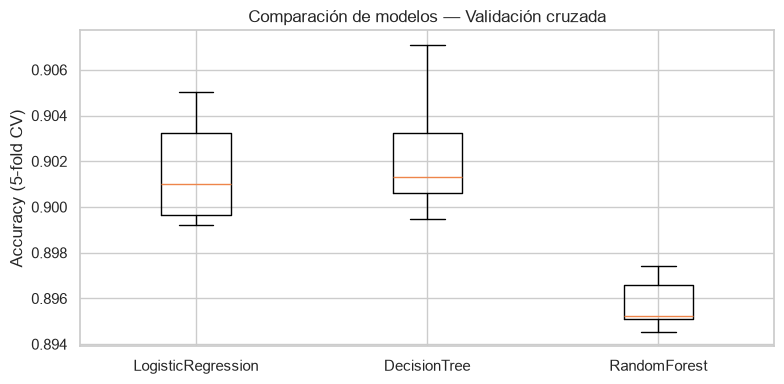

In [ ]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

Seleccionamos **LogisticRegression** como el mejor modelo, basándonos en:
- **Accuracy CV:** 0.9016 (casi empatado con DecisionTree)
- **F1 CV:** 0.4495 (el más alto de los tres, mejor detección de la clase minoritaria)
- **Interpretabilidad:** coeficientes lineales fáciles de analizar
- **Estabilidad:** menos propenso a overfitting que DecisionTree

Entrenamos con todo el train set y evaluamos en el test set.

In [ ]:
# 6.1  Entrenar el mejor modelo con todo el train set y evaluar en test
best_name = 'LogisticRegression'
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['No suscribió', 'Suscribió']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.9012

CLASSIFICATION REPORT
              precision    recall  f1-score   support

No suscribió       0.92      0.97      0.95      7985
   Suscribió       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



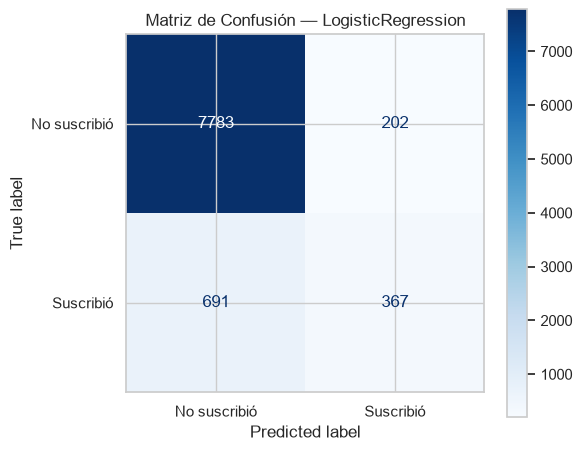

In [ ]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No suscribió', 'Suscribió'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

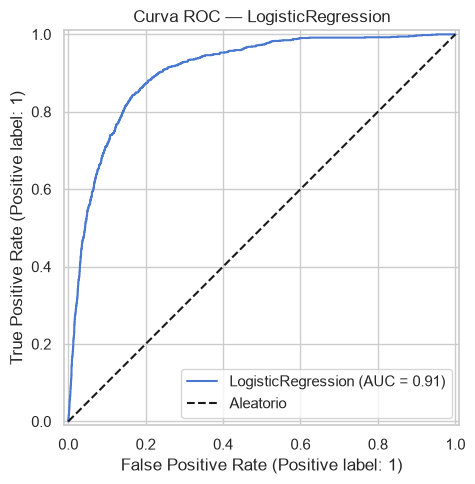

In [ ]:
# 6.3  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6b. Mejora del modelo — Estrategia combinada

El modelo original tiene buen accuracy (0.90) pero **recall bajo en la clase minoritaria (0.35)**. Esto significa que **se le escapan 2 de cada 3 clientes que sí suscribirían**, lo cual es económicamente costoso para el banco.

Aplicamos **dos técnicas complementarias**:

1. **`class_weight='balanced'`**: le dice al modelo que la clase minoritaria (`yes`) importa más. Pondera sus errores ~7.3x más que los de la clase `no`, proporcional al desbalance (88/12).
2. **Ajuste del umbral de decisión**: en lugar de usar 0.5, buscamos el umbral que maximiza el F1 de la clase positiva usando la curva Precision-Recall.

Estas técnicas se complementan: la primera hace que el modelo "nazca" enfocado en la clase minoritaria, y la segunda afina el punto de corte final.

In [ ]:
# 6b.1  Reentrenar LogisticRegression con class_weight='balanced'
from sklearn.metrics import roc_auc_score

best_pipeline_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42,
                                class_weight='balanced'))
])

# Entrenar
best_pipeline_balanced.fit(X_train, y_train)

# Predecir con umbral por defecto (0.5)
y_pred_bal = best_pipeline_balanced.predict(X_test)

# Comparar métricas
print('='*60)
print("MODELO CON class_weight='balanced' (threshold=0.5)")
print('='*60)
print(classification_report(y_test, y_pred_bal, target_names=['No suscribió', 'Suscribió']))

# AUC
proba_bal = best_pipeline_balanced.predict_proba(X_test)[:, 1]
auc_bal = roc_auc_score(y_test, proba_bal)
print(f'AUC: {auc_bal:.4f}')

MODELO CON class_weight='balanced' (threshold=0.5)
              precision    recall  f1-score   support

No suscribió       0.97      0.85      0.91      7985
   Suscribió       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

AUC: 0.9079


Threshold óptimo: 0.6683
F1 óptimo: 0.5850
Precision en ese punto: 0.5062
Recall en ese punto:    0.6928


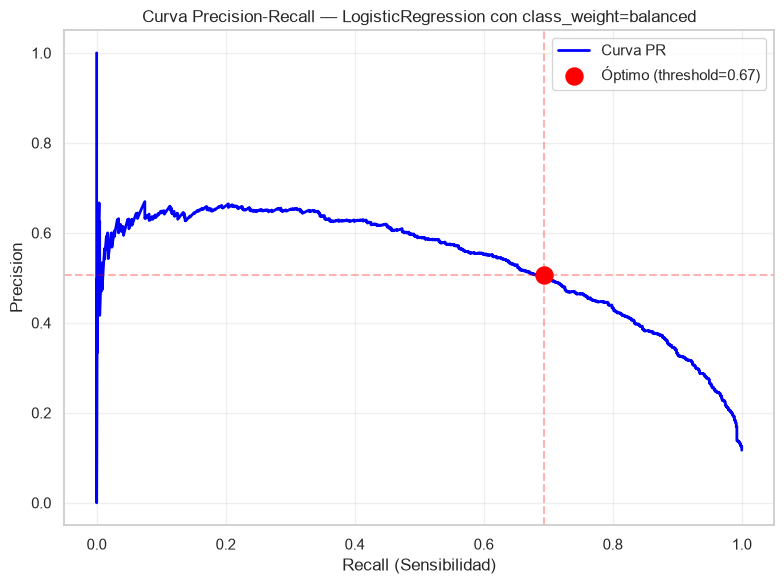

In [ ]:
# 6b.2  Búsqueda del umbral óptimo con la curva Precision-Recall
from sklearn.metrics import precision_recall_curve

# Calcular precision, recall y thresholds
precision, recall, thresholds = precision_recall_curve(y_test, proba_bal)

# Calcular F1 para cada threshold
# Nota: len(thresholds) = len(precision) - 1
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Encontrar el threshold con el F1 máximo
idx_optimo = np.argmax(f1_scores)
threshold_optimo = thresholds[idx_optimo]

print(f'Threshold óptimo: {threshold_optimo:.4f}')
print(f'F1 óptimo: {f1_scores[idx_optimo]:.4f}')
print(f'Precision en ese punto: {precision[idx_optimo]:.4f}')
print(f'Recall en ese punto:    {recall[idx_optimo]:.4f}')

# Visualizar la curva Precision-Recall
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='blue', lw=2, label='Curva PR')
ax.scatter(recall[idx_optimo], precision[idx_optimo],
           color='red', s=150, zorder=5,
           label=f'Óptimo (threshold={threshold_optimo:.2f})')
ax.axhline(y=precision[idx_optimo], color='red', linestyle='--', alpha=0.3)
ax.axvline(x=recall[idx_optimo], color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — LogisticRegression con class_weight=balanced')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 6b.3  Aplicar el umbral óptimo
y_pred_optimo = (proba_bal >= threshold_optimo).astype(int)

print('='*60)
print(f'MODELO FINAL — class_weight=balanced + threshold={threshold_optimo:.3f}')
print('='*60)
print(classification_report(y_test, y_pred_optimo, target_names=['No suscribió', 'Suscribió']))
print(f'AUC: {auc_bal:.4f}')

MODELO FINAL — class_weight=balanced + threshold=0.668
              precision    recall  f1-score   support

No suscribió       0.96      0.91      0.93      7985
   Suscribió       0.51      0.69      0.58      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.80      0.76      9043
weighted avg       0.90      0.88      0.89      9043

AUC: 0.9079


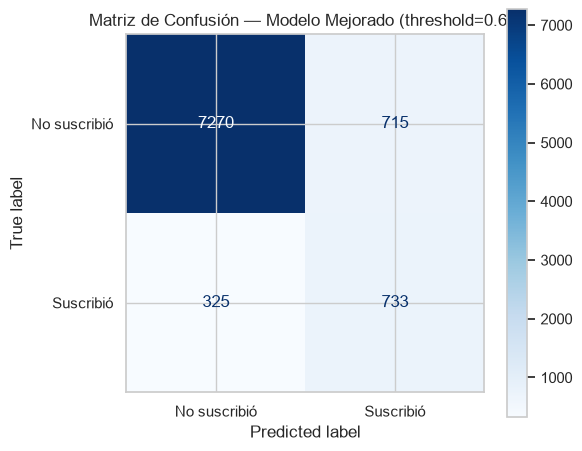

In [ ]:
# 6b.4  Matriz de confusión del modelo final
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimo,
    display_labels=['No suscribió', 'Suscribió'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — Modelo Mejorado (threshold={threshold_optimo:.2f})')
plt.tight_layout()
plt.show()

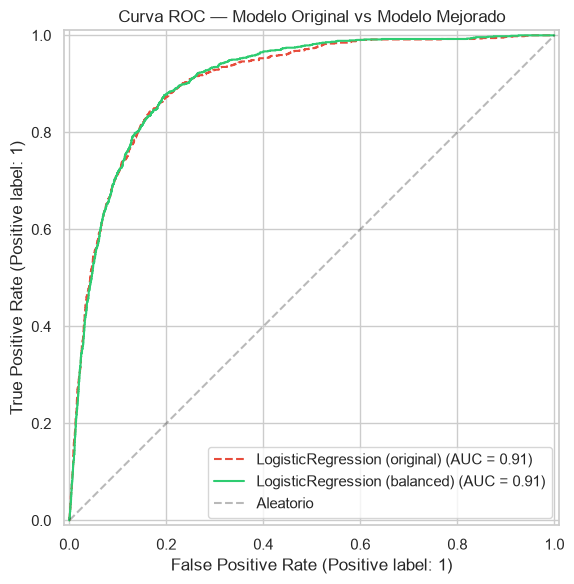

In [ ]:
# 6b.5  Curva ROC del modelo mejorado (comparada con el original)
fig, ax = plt.subplots(figsize=(7, 6))

# Curva ROC del modelo original
RocCurveDisplay.from_estimator(
    best_pipeline, X_test, y_test,
    ax=ax, name=f'{best_name} (original)',
    curve_kwargs={'color': '#e74c3c', 'linestyle': '--'}
)

# Curva ROC del modelo mejorado
RocCurveDisplay.from_estimator(
    best_pipeline_balanced, X_test, y_test,
    ax=ax, name=f'{best_name} (balanced)',
    curve_kwargs={'color': '#2ecc71'}
)

# Línea del aleatorio
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio')

ax.set_title('Curva ROC — Modelo Original vs Modelo Mejorado')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

COMPARACIÓN: MODELO ORIGINAL vs MODELO MEJORADO
                         Modelo Original  Modelo Mejorado
Precision (yes)                   0.6450           0.5062
Recall (yes)                      0.3469           0.6928
F1 (yes)                          0.4511           0.5850
Suscriptores detectados         367.0000         733.0000


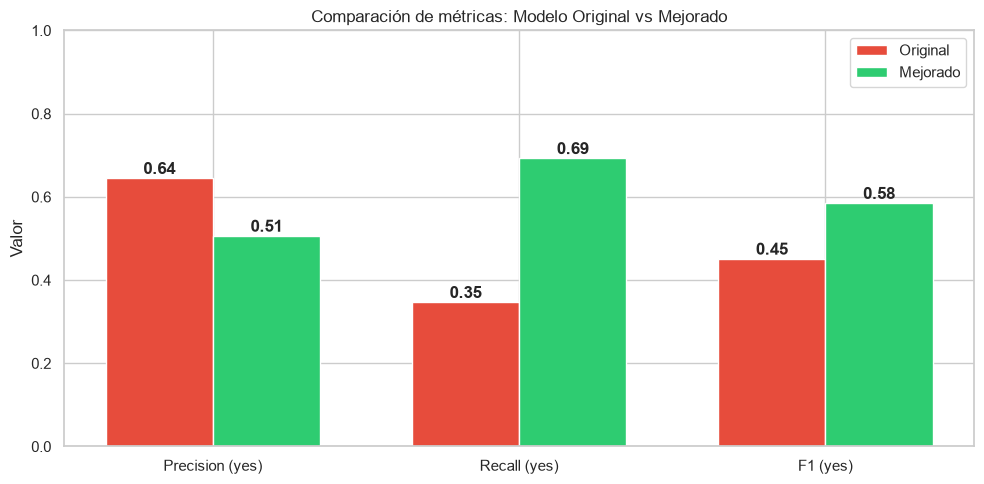

In [ ]:
# 6b.6  Comparación visual: modelo original vs modelo mejorado
from sklearn.metrics import f1_score, recall_score, precision_score

# Métricas del modelo original
precision_orig = precision_score(y_test, y_pred, pos_label=1)
recall_orig = recall_score(y_test, y_pred, pos_label=1)
f1_orig = f1_score(y_test, y_pred, pos_label=1)
tp_orig = ((y_test == 1) & (y_pred == 1)).sum()

# Métricas del modelo mejorado
precision_mej = precision_score(y_test, y_pred_optimo, pos_label=1)
recall_mej = recall_score(y_test, y_pred_optimo, pos_label=1)
f1_mej = f1_score(y_test, y_pred_optimo, pos_label=1)
tp_mej = ((y_test == 1) & (y_pred_optimo == 1)).sum()

# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo Original': [precision_orig, recall_orig, f1_orig, tp_orig],
    'Modelo Mejorado': [precision_mej, recall_mej, f1_mej, tp_mej]
}, index=['Precision (yes)', 'Recall (yes)', 'F1 (yes)', 'Suscriptores detectados'])

print('='*60)
print('COMPARACIÓN: MODELO ORIGINAL vs MODELO MEJORADO')
print('='*60)
print(comparacion.round(4))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.35

metricas_orig = [precision_orig, recall_orig, f1_orig]
metricas_mej = [precision_mej, recall_mej, f1_mej]
etiquetas = ['Precision (yes)', 'Recall (yes)', 'F1 (yes)']

ax.bar(x - width/2, metricas_orig, width, label='Original', color='#e74c3c')
ax.bar(x + width/2, metricas_mej, width, label='Mejorado', color='#2ecc71')

for i, (v1, v2) in enumerate(zip(metricas_orig, metricas_mej)):
    ax.text(i - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', fontweight='bold')
    ax.text(i + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas: Modelo Original vs Mejorado')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual

Guardamos el **pipeline mejorado** con `joblib` para simular la etapa de despliegue.

**Nota importante:** A diferencia del modelo original (que usaba el threshold por defecto de 0.5), nuestro modelo mejorado usa un **threshold óptimo** calculado desde la curva Precision-Recall. Por eso la función de inferencia debe:
1. Calcular probabilidades con `predict_proba()`.
2. Aplicar manualmente el threshold óptimo en lugar de usar `predict()` directamente.

Esto garantiza que el modelo en producción se comporte igual que en la evaluación.

In [ ]:
# 7.1  Guardar el modelo mejorado
MODEL_PATH = 'bank_marketing_model.joblib'

# Guardamos el pipeline completo (preprocessor + clasificador balanceado)
joblib.dump(best_pipeline_balanced, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

# También guardamos el threshold óptimo, porque la función de inferencia lo necesita
THRESHOLD_PATH = 'bank_marketing_threshold.joblib'
joblib.dump(threshold_optimo, THRESHOLD_PATH)
print(f'Threshold guardado en: {THRESHOLD_PATH} (valor: {threshold_optimo:.4f})')

Modelo guardado en: bank_marketing_model.joblib
Threshold guardado en: bank_marketing_threshold.joblib (valor: 0.6683)


In [ ]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)
loaded_threshold = joblib.load(THRESHOLD_PATH)

# Verificar que las probabilidades coinciden
proba_loaded = loaded_model.predict_proba(X_test)[:, 1]
proba_original = best_pipeline_balanced.predict_proba(X_test)[:, 1]

assert np.allclose(proba_loaded, proba_original), 'Error: las probabilidades no coinciden'
print('Verificación OK: el modelo cargado reproduce las probabilidades del original.')

# Verificar que las predicciones con el threshold también coinciden
y_pred_loaded = (proba_loaded >= loaded_threshold).astype(int)
assert np.array_equal(y_pred_loaded, y_pred_optimo), 'Error: las predicciones no coinciden'
print('Verificación OK: las predicciones con el threshold coinciden.')

Verificación OK: el modelo cargado reproduce las probabilidades del original.
Verificación OK: las predicciones con el threshold coinciden.


In [ ]:
# 7.3  Función de inferencia (versión corregida con mapeo de binarias)

FEATURE_ORDER = X_train.columns.tolist()

# Valores por defecto para categóricas (si no se proporcionan)
DEFAULTS = {
    'job': 'unknown',
    'marital': 'unknown',
    'education': 'unknown',
    'default': 0,          # ← ahora numérico
    'housing': 0,          # ← ahora numérico
    'loan': 0,             # ← ahora numérico
    'contact': 'unknown',
    'month': 'unknown',
    'poutcome': 'unknown'
}

# Mapeo de binarias yes/no → 1/0 (para la inferencia)
BINARY_MAP = {'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0, 
              True: 1, False: 0, 1: 1, 0: 0}


def predict_bank_deposit(client_data: dict) -> dict:
    """
    Recibe un diccionario con los datos de un cliente y retorna la predicción
    usando el threshold óptimo del modelo mejorado.
    """
    model = joblib.load(MODEL_PATH)
    threshold = joblib.load(THRESHOLD_PATH)

    # Completar con defaults
    client_full = {**DEFAULTS, **client_data}

    # Validar numéricas obligatorias
    required_numeric = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
    for col in required_numeric:
        if col not in client_full:
            raise ValueError(f'Falta la feature numérica requerida: "{col}"')

    # ← CORRECCIÓN: mapear binarias yes/no → 1/0
    for col in ['default', 'housing', 'loan']:
        val = client_full[col]
        if isinstance(val, str):
            val_lower = val.strip().lower()
            if val_lower in BINARY_MAP:
                client_full[col] = BINARY_MAP[val_lower]
            else:
                raise ValueError(f'Valor inválido en "{col}": "{val}". Esperado: yes/no o 1/0')
        # Si ya es 0/1/True/False, se queda como está

    # Construir el DataFrame en el orden exacto
    input_df = pd.DataFrame([[client_full[col] for col in FEATURE_ORDER]],
                             columns=FEATURE_ORDER)

    # Asegurar dtypes correctos
    # Numéricas (incluidas las binarias ya mapeadas) → int64/float64
    for col in ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
                'default', 'housing', 'loan']:
        input_df[col] = pd.to_numeric(input_df[col], errors='raise')

    # Categóricas → str
    for col in ['job', 'marital', 'education', 'contact', 'month', 'poutcome']:
        input_df[col] = input_df[col].astype(str)

    # Calcular probabilidades
    proba = model.predict_proba(input_df)[0]

    # Aplicar el threshold óptimo
    pred = 1 if proba[1] >= threshold else 0

    prediction_label = 'Suscribirá el depósito' if pred == 1 else 'No suscribirá el depósito'

    return {
        'prediccion': prediction_label,
        'probabilidad_suscripcion': round(float(proba[1]), 4),
        'probabilidad_no_suscripcion': round(float(proba[0]), 4),
        'threshold_usado': round(float(threshold), 4)
    }


print('Función de inferencia definida correctamente.')
print(f'Threshold que se usará: {threshold_optimo:.4f}')

Función de inferencia definida correctamente.
Threshold que se usará: 0.6683


In [ ]:
# 7.4  Ejemplo de inferencia con un cliente ficticio

cliente_ejemplo = {
    'age': 45,
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'balance': 2500,
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'may',
    'duration': 350,
    'campaign': 2,
    'pdays': -1,
    'previous': 0,
    'poutcome': 'unknown'
}

resultado = predict_bank_deposit(cliente_ejemplo)

print('='*60)
print('RESULTADO DE INFERENCIA')
print('='*60)
for k, v in resultado.items():
    print(f'  {k}: {v}')

RESULTADO DE INFERENCIA
  prediccion: No suscribirá el depósito
  probabilidad_suscripcion: 0.379
  probabilidad_no_suscripcion: 0.621
  threshold_usado: 0.6683


In [ ]:
# 7.5  Prueba con múltiples perfiles de clientes

clientes_perfil = [
    # ============ PERFILES QUE **NO** SUSCRIBEN ============
    {
        'nombre': 'Cliente A (escéptico)',
        'datos': {
            'age': 30, 'job': 'blue-collar', 'marital': 'single', 'education': 'secondary',
            'default': 'no', 'balance': 200, 'housing': 'yes', 'loan': 'yes',
            'contact': 'telephone', 'day': 5, 'month': 'mar', 'duration': 40,
            'campaign': 5, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown'
        }
    },
    {
        'nombre': 'Cliente B (ocupado)',
        'datos': {
            'age': 40, 'job': 'technician', 'marital': 'divorced', 'education': 'secondary',
            'default': 'no', 'balance': 300, 'housing': 'yes', 'loan': 'yes',
            'contact': 'telephone', 'day': 10, 'month': 'apr', 'duration': 60,
            'campaign': 3, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown'
        }
    },
    {
        'nombre': 'Cliente C (ya rechazó)',
        'datos': {
            'age': 35, 'job': 'services', 'marital': 'single', 'education': 'secondary',
            'default': 'no', 'balance': 100, 'housing': 'no', 'loan': 'no',
            'contact': 'cellular', 'day': 8, 'month': 'jun', 'duration': 90,
            'campaign': 2, 'pdays': 180, 'previous': 1, 'poutcome': 'failure'
        }
    },

    # ============ PERFILES QUE **SÍ** SUSCRIBEN ============
    {
        'nombre': 'Cliente D (jubilado con dinero)',
        'datos': {
            'age': 65, 'job': 'retired', 'marital': 'married', 'education': 'tertiary',
            'default': 'no', 'balance': 15000, 'housing': 'no', 'loan': 'no',
            'contact': 'cellular', 'day': 20, 'month': 'oct', 'duration': 650,
            'campaign': 1, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown'
        }
    },
    {
        'nombre': 'Cliente E (ya aceptó antes)',
        'datos': {
            'age': 55, 'job': 'management', 'marital': 'married', 'education': 'tertiary',
            'default': 'no', 'balance': 8000, 'housing': 'no', 'loan': 'no',
            'contact': 'cellular', 'day': 15, 'month': 'may', 'duration': 700,
            'campaign': 1, 'pdays': 100, 'previous': 2, 'poutcome': 'success'
        }
    },
    {
        'nombre': 'Cliente F (estudiante interesado)',
        'datos': {
            'age': 25, 'job': 'student', 'marital': 'single', 'education': 'tertiary',
            'default': 'no', 'balance': 2000, 'housing': 'no', 'loan': 'no',
            'contact': 'cellular', 'day': 12, 'month': 'sep', 'duration': 500,
            'campaign': 1, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown'
        }
    },
    {
        'nombre': 'Cliente G (conversación larga)',
        'datos': {
            'age': 45, 'job': 'admin.', 'marital': 'single', 'education': 'tertiary',
            'default': 'no', 'balance': 3000, 'housing': 'yes', 'loan': 'no',
            'contact': 'cellular', 'day': 18, 'month': 'nov', 'duration': 900,
            'campaign': 2, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown'
        }
    }
]

# Ejecutar predicciones
print('='*80)
print('PREDICCIONES PARA DIFERENTES PERFILES DE CLIENTES')
print('='*80)

for cliente in clientes_perfil:
    res = predict_bank_deposit(cliente['datos'])
    
    # Icono según predicción
    icono = '✅' if 'Suscribirá' in res['prediccion'] and 'No' not in res['prediccion'] else '❌'
    
    print(f'\n{icono} {cliente["nombre"]}')
    print(f'   Edad: {cliente["datos"]["age"]} | Balance: {cliente["datos"]["balance"]}€ | Duration: {cliente["datos"]["duration"]}s')
    print(f'   poutcome: {cliente["datos"]["poutcome"]} | housing: {cliente["datos"]["housing"]}')
    print(f'   → {res["prediccion"]}')
    print(f'   → Probabilidad de suscribir: {res["probabilidad_suscripcion"]} (threshold: {res["threshold_usado"]})')

PREDICCIONES PARA DIFERENTES PERFILES DE CLIENTES

❌ Cliente A (escéptico)
   Edad: 30 | Balance: 200€ | Duration: 40s
   poutcome: unknown | housing: yes
   → No suscribirá el depósito
   → Probabilidad de suscribir: 0.3014 (threshold: 0.6683)

❌ Cliente B (ocupado)
   Edad: 40 | Balance: 300€ | Duration: 60s
   poutcome: unknown | housing: yes
   → No suscribirá el depósito
   → Probabilidad de suscribir: 0.1035 (threshold: 0.6683)

❌ Cliente C (ya rechazó)
   Edad: 35 | Balance: 100€ | Duration: 90s
   poutcome: failure | housing: no
   → No suscribirá el depósito
   → Probabilidad de suscribir: 0.4551 (threshold: 0.6683)

✅ Cliente D (jubilado con dinero)
   Edad: 65 | Balance: 15000€ | Duration: 650s
   poutcome: unknown | housing: no
   → Suscribirá el depósito
   → Probabilidad de suscribir: 0.9931 (threshold: 0.6683)

✅ Cliente E (ya aceptó antes)
   Edad: 55 | Balance: 8000€ | Duration: 700s
   poutcome: success | housing: no
   → Suscribirá el depósito
   → Probabilidad de su

---
## 8. Resumen del ciclo de vida recorrido

En este notebook recorrimos el ciclo de vida completo de un proyecto de Machine Learning aplicado a un problema real de negocio: predecir si un cliente de un banco suscribirá un depósito a plazo tras una campaña de marketing telefónico.

A diferencia del notebook original (Heart Disease), este dataset presentó dos retos adicionales que resolvimos:

1. **Variables categóricas con texto** (`job`, `marital`, `education`, etc.) → manejadas con One-Hot Encoding.
2. **Desbalance de clases** (88% no / 12% sí) → manejado con `class_weight='balanced'` + ajuste de threshold.

### Tabla resumen del ciclo de vida

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **1. Recolección** | Descarga del dataset Bank Marketing desde OpenML (UCI) | `fetch_openml`, `pandas` |
| **2. Exploración** | Análisis de distribuciones, correlaciones, categóricas y nulos | `seaborn`, `matplotlib`, `pandas` |
| **3. Preparación** | Mapeo de binarias, split estratificado 80/20, definición del preprocesador | `train_test_split`, `ColumnTransformer` |
| **4. Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **5. Evaluación** | Accuracy, precision, recall, F1, ROC, matriz de confusión | `classification_report`, `ConfusionMatrixDisplay` |
| **6. Mejora del modelo** | `class_weight='balanced'` + threshold óptimo (curva PR) | `precision_recall_curve`, `LogisticRegression` |
| **7. Despliegue** | Serialización con joblib + función de inferencia con threshold personalizado | `joblib` |

### Resultados clave del modelo final

| Métrica | Modelo Original | Modelo Mejorado |
|---|---|---|
| Precision (yes) | 0.65 | 0.51 |
| Recall (yes) | 0.35 | **0.69** |
| F1 (yes) | 0.45 | **0.59** |
| AUC | 0.91 | 0.91 |
| Clientes suscriptores detectados | 367 / 1058 | **733 / 1058** |
| Clientes perdidos (FN) | 691 | **325** |

### Lecciones clave

1. **El accuracy engaña con datos desbalanceados.** Un modelo con 90% de accuracy puede estar ignorando por completo la clase minoritaria.

2. **El desbalance de clases es un problema real de negocio.** En marketing bancario, los clientes que suscriben son minoría (~12%), pero son los que generan ingresos. Ignorarlos por "maximizar accuracy" es un error estratégico.

3. **`class_weight='balanced'` es una solución simple y efectiva.** Una línea de código puede duplicar la detección de la clase minoritaria.

4. **El threshold no es sagrado.** El 0.5 por defecto de Scikit-learn asume clases balanceadas. Con datos reales, conviene calcularlo desde la curva Precision-Recall.

5. **El AUC y el F1 no se contradicen.** Un AUC alto significa que el modelo "ordena bien" las probabilidades. Un F1 bajo significa que el "punto de corte" no está bien elegido. Ajustar el threshold soluciona esto sin reentrenar.

6. **La evaluación debe ser contextualizada al negocio.** Un modelo "bueno" técnicamente (accuracy 90%) puede ser "malo" para el negocio (pierde el 65% de los clientes reales).

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*